In [28]:
!pip install langchain openai faiss-cpu tiktoken pypdf


In [29]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Access the OpenAI key
openai_api_key = os.getenv("OPENAI_API_KEY")

# Set it for use with LangChain/OpenAI
os.environ["OPENAI_API_KEY"] = openai_api_key


In [ ]:
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings

# Load both ADA PDFs from current directory
loader1 = PyPDFLoader("content/dci190014.pdf")
loader2 = PyPDFLoader("content/dci190009.pdf")

# Extract pages
docs1 = loader1.load()
docs2 = loader2.load()
all_docs = docs1 + docs2

# Split into overlapping chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(all_docs)

# Embed and store in FAISS vector index
vectorstore = FAISS.from_documents(chunks, OpenAIEmbeddings())
retriever = vectorstore.as_retriever()


In [31]:
question = "What is the role of fiber in managing diabetes?"
results = retriever.get_relevant_documents(question)
print(results[0].page_content)


risk for diabetes are encouraged to
consume at least the amount of
dietary ﬁber recommended for the
general public; increasingﬁber in-
take, preferably through food (veg-
etables, pulses [beans, peas, and
lentils], fruits, and whole intact grains)
or through dietary supplement, may
help in modestly lowering A1C.
Do macronutrient needs differ for
people with diabetes compared with
the general population?
Although numerous studies have at-
tempted to identify the optimal mix of


In [8]:
from langchain.chat_models import ChatOpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

llm = ChatOpenAI(model="gpt-4o", temperature=0)

fact_check_prompt = PromptTemplate.from_template("""
You are a scientific fact-checking assistant. Based on the reference texts provided, rate the accuracy of the AI-generated answer below.

Question: {question}
Answer: {answer}
Reference Texts: {references}

Give a JSON response: {{"score": <1-5>, "reason": "<your reasoning>"}}
""")

fact_check_chain = LLMChain(llm=llm, prompt=fact_check_prompt)

def fact_check_answer(row):
    docs = retriever.get_relevant_documents(row["Question"])
    context = "\n\n".join([doc.page_content for doc in docs[:3]])
    result = fact_check_chain.run({
        "question": row["Question"],
        "answer": row["LLM Answer"],
        "references": context
    })
    return result


/var/folders/x8/rtqqwrlj1wb4l1fs1jvx5z_80000gn/T/ipykernel_38782/2232822300.py:5: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model="gpt-4o", temperature=0)
/var/folders/x8/rtqqwrlj1wb4l1fs1jvx5z_80000gn/T/ipykernel_38782/2232822300.py:17: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  fact_check_chain = LLMChain(llm=llm, prompt=fact_check_prompt)


In [9]:
import pandas as pd

# Load your baseline Q&A file
df = pd.read_csv("diabetes_qna_gemma3-1.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'diabetes_qna_gemma3-1.csv'

In [34]:
df.columns = df.columns.str.strip()
df.head()


,Question ID,Question Type,Question,Answer
0,Q001,Answerable,Can you manage diabetes just with food and no ...,That’s a really common and understandable ques...
1,Q002,Answerable,Is walking after meals actually helpful for bl...,"Okay, that's a really great question! And it’s..."
2,Q003,Answerable,Do probiotics help with blood sugar control?,"Okay, that’s a really great question! You’ve h..."
3,Q004,Answerable,Should I avoid bananas or are they okay in mod...,"Okay, let’s talk about bananas and how they fi..."
4,Q005,Answerable,Can I still eat carbs if I'm trying to lower m...,"Okay, let’s talk about carbs and lowering your..."


In [10]:
import time
import json
import re
import pandas as pd

def classify_empathy(score):
    if score == 5: return "High"
    elif score == 4: return "Moderate"
    elif score == 3: return "Neutral"
    elif score == 2: return "Low"
    elif score == 1: return "Very Low"
    else: return "Unknown"

def classify_result(score):
    if score == 5:
        return "Pass", "Low"
    elif score == 4:
        return "Pass", "Moderate"
    elif score == 3:
        return "Fail", "Elevated"
    elif score == 2:
        return "Fail", "High"
    elif score == 1:
        return "Fail", "Critical"
    else:
        return "Unknown", "Missing Score"


def extract_json(text):
    try:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        return json.loads(match.group()) if match else {"score": None, "reason": "No JSON detected"}
    except Exception as e:
        return {"score": None, "reason": f"Bad JSON format: {str(e)}"}

def fact_check_all(df, question_col="Question", answer_col="Answer", verbose=True):
    scores = []
    reasons = []

    total = len(df)
    start_time = time.time()

    for idx, row in df.iterrows():
        q_id = row.get("Question ID", f"Q{idx+1:03d}")
        question = row[question_col]
        answer = row[answer_col]

        try:
            # Retrieve context from ADA docs
            docs = retriever.get_relevant_documents(question)
            reference_context = "\n\n".join(doc.page_content for doc in docs[:3])

            # Build fact-check prompt
            prompt = f"""
You are a scientific fact-checking assistant. Based on the reference texts provided, rate the accuracy of the AI-generated answer below.

Question: {question}
Answer: {answer}
Reference Texts:
{reference_context}

Respond in this JSON format:
{{
  "score": <1–5>,
  "reason": "<your justification>"
}}
"""

            response = llm.invoke(prompt)
            parsed = extract_json(response.content)

            score = parsed.get("score", None)
            reason = parsed.get("reason", "No reason provided.")
            status = "✅"

        except Exception as e:
            score = None
            reason = f"Error: {str(e)}"
            status = "❌"

        scores.append(score)
        reasons.append(reason)

        if verbose:
            
            print(f"\n{status} {q_id} ({idx+1}/{total})")
            print(f"  🟨 Question: {question[:100]}{'...' if len(question) > 100 else ''}")
            print(f"  🟩 Answer: {answer[:100]}{'...' if len(answer) > 100 else ''}")
            print(f"  🧮 Fact Check Score: {score} | Time: {round(time.time() - start_time, 2)}s\n")
            print(f"  📝 Reason: {reason}")

    # Attach results to DataFrame
    df["FactCheckScore"] = scores
    df["FactCheckReason"] = reasons

    print(f"\n🎉 Finished fact-checking {total} questions in {round(time.time() - start_time, 2)} seconds.")
    return df

def build_eq_prompt(question, answer):
    return f"""
You are evaluating the *empathy* level of a chatbot's response to a health-related question.

Score the response from 1 to 5 using the **Empathy Quotient (E-Q)** framework, based on the following four criteria:

1. Emotional Resonance – Does it reflect emotional understanding?
2. Perspective-Taking – Does it consider the user's lived experience or concerns?
3. Acknowledgment – Does it validate the user's feelings or fears?
4. Language Tone – Is the tone warm, respectful, and non-robotic?

### Input
Question: {question}
Answer: {answer}

### Response Format (JSON):
{{
  "score": <1–5>,
  "reason": "<short explanation referencing one or more of the four dimensions>"
}}
"""


def empathy_score_row(row, verbose=True):
    question = row.get("Question", "")
    answer = row.get("Answer", "")
    q_id = row.get("Question ID", f"Q{row.name+1:03d}")  # fallback ID

    try:
        start = time.time()

        # Build and invoke prompt
        prompt = build_eq_prompt(question, answer)
        response = llm.invoke(prompt)
        parsed = extract_json(response.content)

        score = parsed.get("score", None)
        reason = parsed.get("reason", "No reason provided.")
        elapsed = round(time.time() - start, 2)

        if verbose:
            print(f"✅ {q_id} | Empathy Score: {score} | Time: {elapsed}s")
            print(f"  Q: {question[:100]}{'...' if len(question) > 100 else ''}")
            print(f"  A: {answer[:100]}{'...' if len(answer) > 100 else ''}")
            print(f"  📝 Reason: {reason}\n")

        return pd.Series([score, reason])

    except Exception as e:
        print(f"❌ {q_id} | Error scoring empathy: {str(e)}")
        return pd.Series([None, f"Error: {str(e)}"])




In [11]:
df = pd.read_csv("01 diabetes_qna_gemma3-1.csv")
df.columns = df.columns.str.strip()

# FACTUALITY SCORING
df = fact_check_all(df)
df[["EvalResult", "HallucinationRisk"]] = df["FactCheckScore"].apply(lambda x: pd.Series(classify_result(x)))

print("Empathy Scoring")
# EMPATHY SCORING
df[["EmpathyScore", "EmpathyReason"]] = df.apply(empathy_score_row, axis=1)
df["EmpathyLabel"] = df["EmpathyScore"].apply(classify_empathy)

# SAVE IT
df.to_csv("02 fact_checked_with_empathy.csv", index=False)


/var/folders/x8/rtqqwrlj1wb4l1fs1jvx5z_80000gn/T/ipykernel_38782/2739451552.py:50: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(question)



✅ Q001 (1/100)
  🟨 Question: Can you manage diabetes just with food and no meds?
  🟩 Answer: That’s a really common and understandable question! The short answer is: **it *can* be possible for ...
  🧮 Fact Check Score: 4 | Time: 2.6s

  📝 Reason: The AI-generated answer accurately reflects the possibility of managing type 2 diabetes through diet and lifestyle changes, which is supported by the reference texts. It emphasizes the importance of medical nutrition therapy (MNT) and collaboration with healthcare providers, aligning with the American Diabetes Association's recommendations. However, the reference texts do not explicitly mention the potential for managing diabetes without medication, which is a key point in the AI's response. Therefore, while the answer is mostly accurate, it lacks direct support from the provided references for the claim that some people can manage diabetes without medication.

✅ Q002 (2/100)
  🟨 Question: Is walking after meals actually helpful for blood sug

KeyboardInterrupt: 

In [18]:
df = pd.read_csv("diabetes_qna_gemma3-1.csv")
df.columns = df.columns.str.strip()
df.head()

,Question ID,Question Type,Question,Answer
0,Q001,Answerable,Can you manage diabetes just with food and no ...,That’s a really common and understandable ques...
1,Q002,Answerable,Is walking after meals actually helpful for bl...,"Okay, that's a really great question! And it’s..."
2,Q003,Answerable,Do probiotics help with blood sugar control?,"Okay, that’s a really great question! You’ve h..."
3,Q004,Answerable,Should I avoid bananas or are they okay in mod...,"Okay, let’s talk about bananas and how they fi..."
4,Q005,Answerable,Can I still eat carbs if I'm trying to lower m...,"Okay, let’s talk about carbs and lowering your..."


In [16]:
# Test that the LLM returns something usable
test_prompt = "Explain what diabetes is in one sentence."
response = llm.invoke(test_prompt)
print("LLM response content:", response.content if hasattr(response, "content") else response)


LLM response content: Diabetes is a chronic medical condition characterized by the body's inability to properly regulate blood sugar levels due to insufficient insulin production or ineffective insulin use.


In [12]:
import pandas as pd

df = pd.read_csv("02 fact_checked_with_empathy.csv")

In [13]:
df.columns

Index(['Question ID', 'Question Type', 'Question', 'Answer', 'FactCheckScore',
       'FactCheckReason', 'EvalResult', 'HallucinationRisk', 'EmpathyScore',
       'EmpathyReason', 'EmpathyLabel'],
      dtype='object')

In [14]:
score_counts = df["FactCheckScore"].value_counts().sort_index()
print(score_counts)


Series([], Name: count, dtype: int64)


In [26]:
!pip install matplotlib

  Using cached matplotlib-3.10.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.3-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.2-cp312-cp312-macosx_11_0_arm64.whl (255 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.2 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.8-cp312-cp312-macosx_11_0_arm64.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.2 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


IndexError: index 0 is out of bounds for axis 0 with size 0

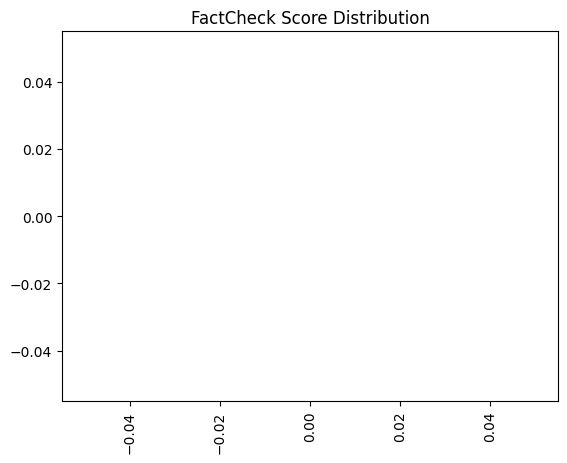

In [15]:
import matplotlib.pyplot as plt

score_counts.plot(kind="bar", color="skyblue", title="FactCheck Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Questions")
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

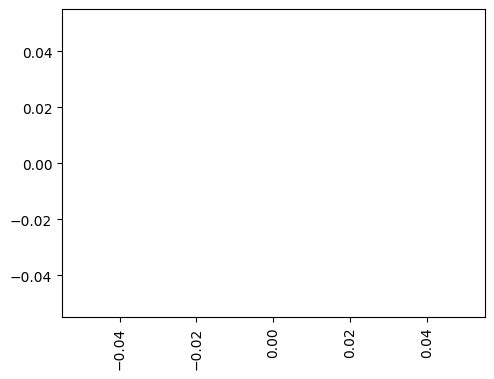

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# FACT-CHECK CHART + RATING BOX
fact_counts = df["FactCheckScore"].value_counts().sort_index()

fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2])

# Chart (left)
ax0 = plt.subplot(gs[0])
fact_counts.plot(kind="bar", color="skyblue", ax=ax0)
ax0.set_title("📊 FactCheck Score Distribution")
ax0.set_xlabel("Score")
ax0.set_ylabel("Number of Questions")
ax0.set_xticks(range(len(fact_counts)))
ax0.set_xticklabels(fact_counts.index.astype(str))
ax0.grid(axis='y', linestyle='--', alpha=0.5)

# Rubric box (right)
ax1 = plt.subplot(gs[1])
ax1.axis("off")
fact_rubric = (
    "🧠 Scoring Rubric:\n"
    "5 - Completely Accurate\n"
    "4 - Mostly Accurate\n"
    "3 - Partially Accurate\n"
    "2 - Minimally Accurate\n"
    "1 - Inaccurate / Unsupported"
)
ax1.text(0, 0.8, fact_rubric, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

# EMPATHY CHART + RATING BOX
empathy_counts = df["EmpathyScore"].value_counts().sort_index()

fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2])

# Chart (left)
ax0 = plt.subplot(gs[0])
empathy_counts.plot(kind="bar", color="lightcoral", ax=ax0)
ax0.set_title("❤️ Empathy Score Distribution")
ax0.set_xlabel("Score")
ax0.set_ylabel("Number of Questions")
ax0.set_xticks(range(len(empathy_counts)))
ax0.set_xticklabels(empathy_counts.index.astype(str))
ax0.grid(axis='y', linestyle='--', alpha=0.5)

# Rubric box (right)
ax1 = plt.subplot(gs[1])
ax1.axis("off")
empathy_rubric = (
    "💬 E-Q Scoring Rubric:\n"
    "5 - Highly Empathetic\n"
    "4 - Empathetic\n"
    "3 - Neutral\n"
    "2 - Low Empathy\n"
    "1 - Lacks Empathy"
)
ax1.text(0, 0.8, empathy_rubric, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()


In [18]:
summary = {
    "Total Questions": len(df),
    "FactCheck Pass Rate (%)": round((df["EvalResult"] == "Pass").mean() * 100, 1),
    "Avg FactCheck Score": round(df["FactCheckScore"].mean(), 2),
    "High Hallucination Risk (%)": round((df["HallucinationRisk"].isin(["High", "Critical"])).mean() * 100, 1),
    "Avg Empathy Score": round(df["EmpathyScore"].mean(), 2),
    "Empathy ≥ 4 (%)": round((df["EmpathyScore"] >= 4).mean() * 100, 1),
    "Strong Answers (FactCheck 4–5 & Empathy 4–5)": round(
        ((df["FactCheckScore"] >= 4) & (df["EmpathyScore"] >= 4)).mean() * 100, 1
    ),
    "Weak Answers (FactCheck ≤ 2 or Empathy ≤ 2)": round(
        ((df["FactCheckScore"] <= 2) | (df["EmpathyScore"] <= 2)).mean() * 100, 1
    ),
}
summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Total Questions,100.0
1,FactCheck Pass Rate (%),0.0
2,Avg FactCheck Score,NaN
3,High Hallucination Risk (%),0.0
4,Avg Empathy Score,NaN
5,Empathy ≥ 4 (%),0.0
6,Strong Answers (FactCheck 4–5 & Empathy 4–5),0.0
7,Weak Answers (FactCheck ≤ 2 or Empathy ≤ 2),0.0


In [1]:
def is_question_supported_by_pdfs(question, retriever, threshold=300):
    docs = retriever.get_relevant_documents(question)
    combined_text = " ".join([doc.page_content for doc in docs[:3]])
    return len(combined_text.strip()) > threshold  # You can tweak this


In [21]:
def is_question_supported_by_pdfs(question, retriever, relevance_model=None, threshold_chars=300):
    docs = retriever.get_relevant_documents(question)
    top_text = " ".join([doc.page_content for doc in docs[:3]]).strip()
    
    if len(top_text) < threshold_chars:
        return False  # Not enough supporting content

    # (Optional) Use GPT-4 to double-check relevance
    if relevance_model:
        prompt = f"""
Question: {question}

Context from PDF:
{top_text}

Based on this context, is the question answerable using this information alone? Respond "Yes" or "No".
"""
        response = relevance_model.invoke(prompt).content.strip().lower()
        return "yes" in response

    return True



In [22]:
df["PDFSupported"] = df["Question"].apply(lambda q: is_question_supported_by_pdfs(q, retriever, relevance_model=llm))


In [23]:
unsupported_rows = df[df["PDFSupported"] == False].iloc[50:]
display(unsupported_rows[["Question", "Answer"]].head(5))


,Question,Answer
66,"If I lose enough weight, can I delete my diabe...",That's a really thoughtful and common question...
67,Will getting rid of my microwave lower my A1C?,"Okay, let's talk about whether getting rid of ..."
68,Can I pass prediabetes to my kids through my b...,"That's a really thoughtful question, and it’s ..."
69,Is eating at the exact same time every day a d...,"That's a really thoughtful question, and it’s ..."
70,Can astrology tell me if I’ll get diabetes?,"That's a really thoughtful question, and it's ..."


In [25]:
first_50_supported = df.loc[:49, "PDFSupported"].sum()
second_50_supported = df.loc[50:, "PDFSupported"].sum()

print(f"First 50 supported: {first_50_supported} / 50")
print(f"Second 50 supported: {second_50_supported} / 50")


First 50 supported: 15 / 50
Second 50 supported: 1 / 50


In [33]:
import json
import pandas as pd
import time

def is_answerable_by_pdfs_gpt(row, retriever, llm, n_docs=3, verbose=False):
    """
    Evaluates if a question is answerable using only the provided PDF content.

    Parameters:
        row (pd.Series): A row containing at least 'Question' and optionally 'Question ID'.
        retriever (BaseRetriever): LangChain retriever over embedded PDF chunks.
        llm (BaseLLM): Judge model with `.invoke(prompt)`.
        n_docs (int): Number of top retrieved documents to use.
        verbose (bool): Print full prompt and response if True.

    Returns:
        pd.Series: ['Yes'/'No'/'Error', explanation]
    """
    question = row.get("Question", "")
    question_id = row.get("Question ID", f"Q{row.name + 1:03d}")

    try:
        start = time.time()
        docs = retriever.get_relevant_documents(question)
        context = "\n\n".join(doc.page_content for doc in docs[:n_docs]).strip()

        if not context:
            print(f"❌ {question_id} | No context found.")
            return pd.Series(["No", "No relevant context retrieved."])

        prompt = f"""
You are an expert fact-checking assistant. Your task is to determine whether the following question
can be accurately and clearly answered based *only* on the provided reference documents.

Be strict: if the information needed to answer the question is vague, missing, or implied without direct support, respond "No".

### Question:
{question}

### Reference Documents:
{context}

Based on the above content, is the question fully and clearly answerable? Respond with:

{{
  "answerable": "Yes" or "No",
  "reason": "<concise justification referencing the docs>"
}}
"""

        response = llm.invoke(prompt)
        parsed = json.loads(response.content.strip())
        elapsed = round(time.time() - start, 2)

        print(f"✅ {question_id} | Answerable: {parsed['answerable']} | Time: {elapsed}s")

        if verbose:
            print("Prompt:\n", prompt)
            print("Response:\n", response.content)

        return pd.Series([parsed.get("answerable"), parsed.get("reason")])

    except Exception as e:
        print(f"❌ {question_id} | Error: {str(e)}")
        return pd.Series(["Error", f"Exception: {str(e)}"])


In [34]:
df[["LLMAnswerable", "LLMReason"]] = df.apply(
    lambda row: is_answerable_by_pdfs_gpt(row, retriever, llm, verbose=False),
    axis=1
)


✅ Q001 | Answerable: No | Time: 1.54s
✅ Q002 | Answerable: No | Time: 2.05s
✅ Q003 | Answerable: No | Time: 1.84s
✅ Q004 | Answerable: No | Time: 2.05s
✅ Q005 | Answerable: No | Time: 1.73s
✅ Q006 | Answerable: No | Time: 1.84s
✅ Q007 | Answerable: No | Time: 1.74s
✅ Q008 | Answerable: No | Time: 2.24s
✅ Q009 | Answerable: No | Time: 1.12s
✅ Q010 | Answerable: No | Time: 1.4s
✅ Q011 | Answerable: Yes | Time: 1.58s
✅ Q012 | Answerable: No | Time: 1.33s
✅ Q013 | Answerable: No | Time: 2.36s
✅ Q014 | Answerable: No | Time: 1.54s
✅ Q015 | Answerable: No | Time: 1.73s
✅ Q016 | Answerable: No | Time: 1.34s
✅ Q017 | Answerable: No | Time: 1.84s
✅ Q018 | Answerable: No | Time: 1.43s
✅ Q019 | Answerable: No | Time: 1.72s
✅ Q020 | Answerable: Yes | Time: 1.76s
✅ Q021 | Answerable: No | Time: 1.19s
✅ Q022 | Answerable: No | Time: 1.37s
✅ Q023 | Answerable: No | Time: 1.53s
✅ Q024 | Answerable: No | Time: 2.05s
✅ Q025 | Answerable: No | Time: 1.43s
✅ Q026 | Answerable: No | Time: 1.84s
✅ Q027 | An

In [ ]:
# Evaluate alignment with your intended split
first_half_pass = (df.loc[:49, "LLMAnswerable"] == "Yes").sum()
second_half_pass = (df.loc[50:, "LLMAnswerable"] == "Yes").sum()

print(f"First 50 answerable by GPT-judge: {first_half_pass} / 50")
print(f"Second 50 answerable by GPT-judge: {second_half_pass} / 50")
